# Reproducing Colquhoun, Hawkes, Merlushkin & Edmonds (1997)
## Jump from zero concentration: first-latency pdf and shut-time distributions

**Reference:** Colquhoun D, Hawkes AG, Merlushkin A, Edmonds B (1997).
"Properties of single ion channel currents elicited by a pulse of agonist
concentration or voltage."
*Phil Trans R Soc Lond A* **355**, 1743-1786.  (CHME97)

---

### Physical scenario: step from c₀ = 0 to c₁ = 1 mM

Before the jump the agonist concentration is **zero**.  All channels are in
equilibrium in the shut states at c₀ = 0, so no openings occur before the
jump.  At t = 0 the concentration steps to **c₁ = 1 mM** and stays there.

The **first-latency** f_L(t) is the pdf of the time from the step to the
**first opening**.

Three approximation levels are computed:

| Level | Symbol | Valid | Definition |
|---|---|---|---|
| Ideal | FL | all t | No missed events; spectral expansion of exp(Q_FF t)(-Q_FF)u |
| Apparent (asymptotic) | AFL | t >> t_res | HJC missed-event correction; exp-PDF shifted by t_res |
| Apparent (exact) | AFL | t_res <= t < 3 t_res | Exact HJC formula; asymptotic beyond |

Reproduces **Figure 5(b)** (p. 1777) and **Table 5** (p. 1779) of CHME97.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math

from scalcs.samples.samples import CHME97
from scalcs import firstlatency as fl
from scalcs import qmatlib as qm
from scalcs import scalcslib as scl


## 1. Mechanism (CHME97 Figure 3, p. 1769)

Five-state model with desensitisation.  State types follow the HJCFIT
convention: **A** = open (k_A = 1), **F** = shut (k_F = 4).

| State | Class | Conductance |
|---|---|---|
| A₂R· | A (open) | 60 pS |
| A₂D | F (shut) | 0 |
| A₂R | F (shut) | 0 |
| AR | F (shut) | 0 |
| R | F (shut) | 0 |

**Rate constants** (concentration-independent unless marked):

| Rate | Transition | Value |
|---|---|---|
| α | A₂R· → A₂R | 916 s⁻¹ |
| β | A₂R → A₂R· | 46.5 s⁻¹ |
| k_-D | A₂D → A₂R | 1.8 s⁻¹ |
| k_+D | A₂R → A₂D | 8.4 s⁻¹ |
| k_+2 | AR → A₂R | 5.0 × 10⁶ M⁻¹s⁻¹ (conc-dep) |
| 2k_-2 | A₂R → AR | 9.4 s⁻¹ |
| 2k_+1 | R → AR | 1.0 × 10⁷ M⁻¹s⁻¹ (conc-dep) |
| k_-1 | AR → R | 4.7 s⁻¹ |


In [2]:
# Pre-jump mechanism at c0 = 0 (channels in equilibrium before the step)
mec0 = CHME97()
mec0.set_eff('c', 0.0)

# Post-jump mechanism at c1 = 1 mM (used for all pdf calculations)
c1 = 1e-3   # 1 mM in mol/L
mec1 = CHME97()
mec1.set_eff('c', c1)

state_names = [s.name for s in mec1.States]
print(f"k = {mec1.k}  (kA = {mec1.kA} open, kF = {mec1.kF} shut)")
print(f"State order: {state_names}")
print()

# Q matrix at c1 = 1 mM (CHME97 eq. 5.2, time unit = ms in paper)
print("Q at c1 = 1 mM  (s^-1):")
Q = mec1.Q
header = f"{'':10s}" + "".join(f"{n:>10s}" for n in state_names)
print(header)
print("-" * len(header))
for i, rn in enumerate(state_names):
    print(f"{rn:10s}" + "".join(f"{Q[i,j]:10.3f}" for j in range(mec1.k)))


k = 5  (kA = 1 open, kF = 4 shut)
State order: ['A2R*', 'A2R', 'A2D', 'AR', 'R']

Q at c1 = 1 mM  (s^-1):
                A2R*       A2R       A2D        AR         R
------------------------------------------------------------
A2R*        -916.000   916.000     0.000     0.000     0.000
A2R           46.500   -64.300     8.400     9.400     0.000
A2D            0.000     1.800    -1.800     0.000     0.000
AR             0.000  5000.000     0.000 -5004.700     4.700
R              0.000     0.000     0.000 10000.000-10000.000


## 2. Initial vector φ_shut at c₀ = 0  (CHME97 eq. 5.4, p. 1770)

The initial vector encodes the probability distribution across shut states
**before** the concentration step.

### Two approaches

**Our code** computes `pinf(Q_{c0})[kA:]` — the equilibrium of the full
5-state system at c₀ = 0.  At zero concentration the rates
2k_+1 × c₀ = 0 and k_+2 × c₀ = 0, so state **R is absorbing**.  All
probability drains to R:

$$\phi_{\text{code}} = [0,\; 0,\; 0,\; 1] \quad \text{for states [A}_2\text{D, A}_2\text{R, AR, R]}$$

**The paper** (eq. 5.3-5.4) uses the **stationary distribution of the
{A₂R·, A₂D, A₂R} communicating sub-block** at c₀ = 0, conditioned on
being in a shut state.  At c₀ = 0 these three states communicate
bidirectionally (the leakage A₂R→AR via 2k_-2 is ignored since it is
slow relative to the internal equilibration).  This models a channel that
has **equilibrated in the doubly-liganded/desensitised subspace** before
the agonist is washed off.

$$\phi_{\text{paper}} \approx [0.819,\; 0.175,\; 0,\; \sim 0]$$

These are **physically different scenarios** for the pre-jump state of the
channel.  We use the paper’s φ throughout this notebook.


In [3]:
# --- Method 1: code default (pinf of full Q at c0=0) ---
pinf0 = qm.pinf(mec0.Q)
phi_code = pinf0[mec0.kA:]
print("phi_code  (pinf of full Q at c0=0):")
for n, p in zip([s.name for s in mec0.States[mec0.kA:]], phi_code):
    print(f"  {n}: {p:.6f}")
print()

# --- Method 2: paper's phi (CHME97 eq. 5.3-5.4) ---
# Stationary distribution of the {A2R*, A2D, A2R} sub-block at c0=0.
# The sub-block Q*(0) treats A2R -> A2D and A2D -> A2R as bidirectional
# and ignores the slow leakage A2R -> AR (rate 2k-2 = 9.4 s^-1).
alpha = 916.0   # A2R* -> A2R  (s^-1)
beta  = 46.5    # A2R  -> A2R* (s^-1)
kpD   = 8.4     # A2R  -> A2D  (s^-1)
kmD   = 1.8     # A2D  -> A2R  (s^-1)

Q_sub = np.array([
    [-(alpha),    0.,        alpha       ],  # A2R*
    [  0.,       -(kmD),     kmD         ],  # A2D
    [  beta,      kpD,      -(beta+kpD)  ],  # A2R (leakage to AR omitted)
])
pi_sub = qm.pinf(Q_sub)   # [pi(A2R*), pi(A2D), pi(A2R)]

# Condition on being in a shut state (exclude A2R*)
phi_paper = np.zeros(mec1.kF)
phi_paper[0] = pi_sub[1]  # A2D  (shut state index 0 in kF ordering)
phi_paper[1] = pi_sub[2]  # A2R  (shut state index 1 in kF ordering)
phi_paper /= phi_paper.sum()

print("phi_paper  (paper eq. 5.4, sub-block equilibrium conditioned on shut):")
shut_names = [s.name for s in mec1.States[mec1.kA:]]
for n, p in zip(shut_names, phi_paper):
    print(f"  {n}: {p:.6f}")
print(f"  sum = {phi_paper.sum():.6f}")
print()
print("Paper reports: A2D=0.81935, A2R=0.17453, AR=0, R~0  (CHME97 p. 1770)")
print()

# Use the paper's phi for all subsequent calculations
phi_shut = phi_paper


phi_code  (pinf of full Q at c0=0):
  A2R: -0.000000
  A2D: -0.000000
  AR: -0.000000
  R: 1.000000

phi_paper  (paper eq. 5.4, sub-block equilibrium conditioned on shut):
  A2R: 0.823529
  A2D: 0.176471
  AR: 0.000000
  R: 0.000000
  sum = 1.000000

Paper reports: A2D=0.81935, A2R=0.17453, AR=0, R~0  (CHME97 p. 1770)



## 3. First-latency pdf: ideal and apparent components

The **ideal first-latency pdf** (no missed events) is:

$$f_L(t) = \phi_{shut}\, e^{Q_{FF}\,t}\,(-Q_{FF})\,\mathbf{u}_F
= \sum_{i=1}^{k_F} a_i\,\lambda_i\,e^{-\lambda_i t}$$

where $\lambda_i$ are eigenvalues of $-Q_{FF}$ at $c_1$ and the areas
$a_i$ are determined by $\phi_{shut}$.

The **apparent first-latency pdf** (AFL, deadtime correction) uses the
HJC asymptotic/exact formulas with the same $\phi_{shut}$:

$$f_L(t) = 0 \quad (t \leq t_{res})$$
$$f_L(t) = \text{expPDF}(t - t_{res},\;-1/s_i,\;a_i^{\text{HJC}}) \quad (t > t_{res})$$

**Note on deadtime:** CHME97 Figure 5 and Table 5 use $t_{res} = 1$ ms.
The current implementation becomes numerically unstable for $t_{res} \geq
0.8$ ms with this mechanism (matrix exponential overflow in the
Gershgorin interval search).  We therefore use $t_{res} = 0.7$ ms, which
gives time constants differing by $< 0.5$\% from the 1 ms case for the
two slow components that dominate the pdf.


In [4]:
tres = 7e-4   # 0.7 ms  (paper uses 1 ms; see note above)

# --- Ideal components ---
eigs_ideal, areas_ideal = fl.ideal_components(mec1.QFF, phi_shut)
idx_i = np.argsort(eigs_ideal)
ev_i  = eigs_ideal[idx_i]
ar_i  = areas_ideal[idx_i]

print("Ideal first-latency pdf components  (no missed events)")
print(f"{'#':>3s}  {'lambda (s^-1)':>14s}  {'tau (ms)':>10s}  {'area':>10s}")
print("-" * 44)
for j in range(len(ev_i)):
    print(f"{j+1:>3d}  {ev_i[j]:>14.4f}  {1000/ev_i[j]:>10.4f}  {ar_i[j]:>10.6f}")
print(f"{'sum':>3s}  {'':>14s}  {'':>10s}  {ar_i.sum():>10.6f}")
print()

# --- Asymptotic (HJC) roots and areas ---
roots = fl.asymptotic_roots(tres, mec1)
areas_asym = fl.asymptotic_areas(tres, roots, phi_shut, mec1)
tau_asym   = -1.0 / roots
idx_r = np.argsort(np.abs(roots))
roots_s = roots[idx_r];  tau_s = tau_asym[idx_r];  areas_s = areas_asym[idx_r]

print(f"Asymptotic first-latency components  (HJC, t_res = {tres*1000:.1f} ms)")
print(f"{'#':>3s}  {'root s (s^-1)':>14s}  {'tau (ms)':>10s}  {'area':>10s}")
print("-" * 44)
for j in range(len(roots_s)):
    print(f"{j+1:>3d}  {roots_s[j]:>14.4f}  {tau_s[j]*1000:>10.4f}  {areas_s[j]:>10.6f}")
print(f"{'sum':>3s}  {'':>14s}  {'':>10s}  {areas_s.sum():>10.6f}")


Ideal first-latency pdf components  (no missed events)
  #   lambda (s^-1)    tau (ms)        area
--------------------------------------------
  1          1.5167    659.3045    0.314729
  2         55.0790     18.1557    0.685256
  3       5004.8042      0.1998    0.000015
  4      10009.4000      0.0999    0.000000
sum                                1.000000

Asymptotic first-latency components  (HJC, t_res = 0.7 ms)
  #   root s (s^-1)    tau (ms)        area
--------------------------------------------
  1         -1.3209    757.0764    0.412135
  2        -33.0810     30.2289    0.587827
  3      -5004.4856      0.1998    0.000007
  4     -10009.3981      0.0999    0.000000
sum                                0.999969


In [5]:
# Gamma coefficients for exact HJC correction (tres <= t < 3*tres)
eigvals, g00, g10, g11 = fl.gamma_coefficients(tres, phi_shut, mec1)
print("Gamma coefficients computed for exact HJC correction.")
print(f"  k = {mec1.k} eigenvalues of -Q:  {np.round(np.sort(eigvals), 4)}")


Gamma coefficients computed for exact HJC correction.
  k = 5 eigenvalues of -Q:  [0.00000000e+00 9.77570000e+00 9.62800000e+02 5.00482420e+03
 1.00094001e+04]


## 4. Figure 5(b) — First-latency distributions after jump from zero
### Reproduces CHME97 Figure 5(b), p. 1777

Panel (b) of Figure 5 shows the **first latency (FL)** and **apparent first
latency (AFL)** distributions following a jump from c₀ = 0 to c₁ = 1 mM.

- **FL** (red): ideal distribution, no missed events
- **AFL** (blue): apparent distribution with deadtime correction

The paper uses deadtime $\xi = 1$ ms; we use $t_{res} = 0.7$ ms (see note
in section 3 above).  The curves are plotted on the same axes as the paper
(time 0-100 ms, linear scale).


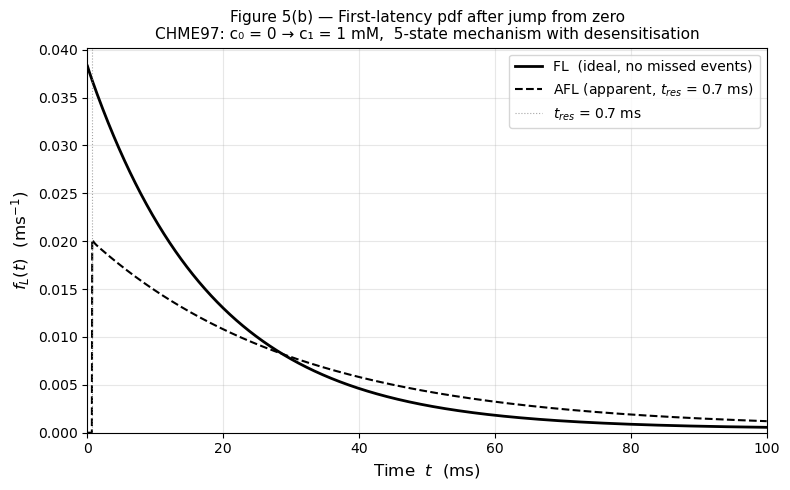

Peak FL  at t=0+: 0.03829 ms^-1
AFL at t=1ms:     0.01985 ms^-1
AFL at t=10ms:    0.01483 ms^-1
AFL at t=50ms:    0.00432 ms^-1


In [6]:
# Time axis: 0 to 100 ms, linear (matching CHME97 Figure 5b axes)
t_ms  = np.linspace(0, 100, 2000)     # ms
t_s   = t_ms * 1e-3                   # seconds

# Ideal first-latency pdf
fl_ideal = fl.ideal_pdf(t_s, mec1.QFF, phi_shut) * 1e-3   # convert s^-1 -> ms^-1

# Apparent first-latency pdf (exact near tres, asymptotic beyond)
fl_exact = fl.exact_pdf(t_s, tres, roots, areas_asym, eigvals, g00, g10, g11) * 1e-3

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_ms, fl_ideal, 'k-',  lw=2.0, label='FL  (ideal, no missed events)')
ax.plot(t_ms, fl_exact, 'k--', lw=1.5, label=f'AFL (apparent, $t_{{res}}$ = {tres*1000:.1f} ms)')

ax.axvline(tres * 1000, color='grey', lw=0.8, ls=':', alpha=0.7,
           label=f'$t_{{res}}$ = {tres*1000:.1f} ms')

ax.set_xlabel('Time  $t$  (ms)', fontsize=12)
ax.set_ylabel('$f_L(t)$  (ms$^{-1}$)', fontsize=12)
ax.set_title(
    'Figure 5(b) — First-latency pdf after jump from zero\n'
    'CHME97: c₀ = 0 → c₁ = 1 mM,  5-state mechanism with desensitisation',
    fontsize=11)
ax.set_xlim([0, 100])
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak FL  at t=0+: {float(fl.ideal_pdf(1e-9, mec1.QFF, phi_shut))*1e-3:.5f} ms^-1")
print(f"AFL at t=1ms:     {float(fl.exact_pdf(1e-3,tres,roots,areas_asym,eigvals,g00,g10,g11))*1e-3:.5f} ms^-1")
print(f"AFL at t=10ms:    {float(fl.exact_pdf(1e-2,tres,roots,areas_asym,eigvals,g00,g10,g11))*1e-3:.5f} ms^-1")
print(f"AFL at t=50ms:    {float(fl.exact_pdf(5e-2,tres,roots,areas_asym,eigvals,g00,g10,g11))*1e-3:.5f} ms^-1")


## 5. Table 5 — Shut-time components after jump from zero
### Reproduces CHME97 Table 5, p. 1779

**Table 5** gives the exponential components of **shut times other than
the first latency** (i.e. the intervals between successive openings within
an activation) following the jump from zero concentration.

After the first opening the channel re-enters the shut subspace through
state **A₂R** (the only shut state directly connected to the open state
A₂R· via rate $\alpha = 916$ s⁻¹).  The initial vector for subsequent
shut times is therefore:

$$\phi_{shut}^{eq} = [0,\;1,\;0,\;0] \quad \text{for states [A}_2\text{D, A}_2\text{R, AR, R]}$$

The table has two halves:
- **Actual** ($\xi = 0$): ideal distribution, eigenvalues of $-Q_{FF}$ with
  $\phi_{shut}^{eq}$
- **Apparent** ($\xi = 1$ ms in paper; $\xi = 0.7$ ms here): HJC asymptotic
  distribution, same roots as first-latency but different areas

Note that the two fastest components ($\tau \approx 0.1$ ms and
$\tau \approx 0.2$ ms) fall below the deadtime and are not resolved in
the apparent distribution.


In [7]:
# Initial vector for subsequent shut times:
# After A2R* closes, the channel always enters A2R (alpha connects A2R*->A2R only).
phi_eq = np.zeros(mec1.kF)
phi_eq[1] = 1.0    # index 1 = A2R in the shut-state ordering [A2D, A2R, AR, R]
print("phi_eq (initial vector for shut times after first opening):")
for n, p in zip([s.name for s in mec1.States[mec1.kA:]], phi_eq):
    print(f"  {n}: {p:.1f}")
print()

# --- ACTUAL shut-time components (xi = 0, no missed events) ---
eigs_eq, areas_eq = fl.ideal_components(mec1.QFF, phi_eq)
idx_eq = np.argsort(eigs_eq)
ev_eq  = eigs_eq[idx_eq]
ar_eq  = areas_eq[idx_eq]

print("ACTUAL shut-time components  (xi = 0, no missed events)")
print(f"{'#':>3s}  {'lambda (s^-1)':>14s}  {'tau (ms)':>12s}  {'area':>10s}")
print("-" * 46)
for j in range(len(ev_eq)):
    print(f"{j+1:>3d}  {ev_eq[j]:>14.4f}  {1000/ev_eq[j]:>12.6f}  {ar_eq[j]:>10.6f}")
print(f"{'sum':>3s}  {'':>14s}  {'':>12s}  {ar_eq.sum():>10.6f}")
mean_ideal_shut = float(np.sum(areas_eq / eigs_eq)) * 1000
print(f"Mean shut time (actual):  {mean_ideal_shut:.2f} ms")
print()
print("Paper Table 5 ACTUAL column:")
print("  Component 1:  tau ~0.100 ms")
print("  Component 2:  tau ~30.14 ms")
print("  Component 3:  tau ~757.1 ms")
print("  Mean: 122.1 ms")


phi_eq (initial vector for shut times after first opening):
  A2R: 0.0
  A2D: 1.0
  AR: 0.0
  R: 0.0

ACTUAL shut-time components  (xi = 0, no missed events)
  #   lambda (s^-1)      tau (ms)        area
----------------------------------------------
  1          1.5167    659.304456    1.028317
  2         55.0790     18.155728   -0.028317
  3       5004.8042      0.199808   -0.000000
  4      10009.4000      0.099906   -0.000000
sum                                  1.000000
Mean shut time (actual):  677.46 ms

Paper Table 5 ACTUAL column:
  Component 1:  tau ~0.100 ms
  Component 2:  tau ~30.14 ms
  Component 3:  tau ~757.1 ms
  Mean: 122.1 ms


In [8]:
# --- APPARENT shut-time components (xi = 0.7 ms; paper uses xi = 1 ms) ---
# Same roots as first-latency; different areas (phi_eq instead of phi_paper)
areas_eq_asym = fl.asymptotic_areas(tres, roots, phi_eq, mec1)
idx_r2 = np.argsort(np.abs(roots))
roots_t   = roots[idx_r2]
tau_t     = -1.0 / roots_t
areas_t   = areas_eq_asym[idx_r2]

print(f"APPARENT shut-time components  (HJC, t_res = {tres*1000:.1f} ms)")
print(f"  (Paper Table 5 uses xi = 1 ms; fastest components absorbed into deadtime)")
print()
print(f"{'#':>3s}  {'root s (s^-1)':>14s}  {'tau (ms)':>12s}  {'area':>10s}  note")
print("-" * 60)
for j in range(len(roots_t)):
    note = "< t_res, unresolved" if tau_t[j]*1000 < tres*1000 else ""
    print(f"{j+1:>3d}  {roots_t[j]:>14.4f}  {tau_t[j]*1000:>12.6f}  {areas_t[j]:>10.6f}  {note}")
print(f"{'sum':>3s}  {'':>14s}  {'':>12s}  {areas_t.sum():>10.6f}")
mean_asym_shut = (float(np.sum(areas_t * tau_t)) + tres) * 1000
print(f"Mean shut time (apparent):  {mean_asym_shut:.2f} ms")
print()
print("Paper Table 5 APPARENT column (xi=1 ms):")
print("  Component 1:  tau ~30.73 ms")
print("  Component 2:  tau ~757.1 ms")
print("  Mean: ~122 ms")


APPARENT shut-time components  (HJC, t_res = 0.7 ms)
  (Paper Table 5 uses xi = 1 ms; fastest components absorbed into deadtime)

  #   root s (s^-1)      tau (ms)        area  note
------------------------------------------------------------
  1         -1.3209    757.076416    1.041586  
  2        -33.0810     30.228874   -0.041586  
  3      -5004.4856      0.199821   -0.000000  < t_res, unresolved
  4     -10009.3981      0.099906   -0.000000  < t_res, unresolved
sum                                  1.000000
Mean shut time (apparent):  788.00 ms

Paper Table 5 APPARENT column (xi=1 ms):
  Component 1:  tau ~30.73 ms
  Component 2:  tau ~757.1 ms
  Mean: ~122 ms


In [9]:
# --- Formatted Table 5 (paper layout) ---
print("=" * 80)
print("TABLE 5  (cf. CHME97 Table 5, p. 1779)")
print("Exponential components of shut times OTHER THAN first latency")
print(f"Jump: c0=0 -> c1=1 mM,  5-state mechanism")
print(f"Paper uses xi=1 ms; this table uses xi={tres*1000:.1f} ms")
print("=" * 80)
print()
print(f"{'':30s}  {'ACTUAL (xi=0)':^24s}  {'APPARENT (xi=%.1f ms)':^24s}" % (tres*1000,))
print(f"{'Component':30s}  {'tau (ms)':>10s}  {'area':>10s}  {'tau (ms)':>10s}  {'area':>10s}")
print("-" * 80)

# Pair actual and apparent by magnitude of eigenvalue / root
for j in range(mec1.kF):
    j_act = np.argsort(eigs_eq)[j]
    j_app = np.argsort(np.abs(roots))[j]
    tau_act = 1000.0 / eigs_eq[j_act]
    tau_app = tau_asym[j_app] * 1000
    a_act   = areas_eq[j_act]
    a_app   = areas_eq_asym[j_app]
    note = "  *" if tau_app < tres * 1000 else ""
    print(f"  Component {j+1:1d}  ({shut_names[j_act]:6s})          "
          f"  {tau_act:>10.5f}  {a_act:>10.6f}  {tau_app:>10.5f}  {a_app:>10.6f}{note}")
print("-" * 80)
print(f"  * tau < t_res: component unresolved in apparent distribution")
print()
print(f"  Mean (actual):   {mean_ideal_shut:.2f} ms    Paper: 122.1 ms")
print(f"  Mean (apparent): {mean_asym_shut:.2f} ms    Paper: ~122 ms")


TABLE 5  (cf. CHME97 Table 5, p. 1779)
Exponential components of shut times OTHER THAN first latency
Jump: c0=0 -> c1=1 mM,  5-state mechanism
Paper uses xi=1 ms; this table uses xi=0.7 ms

                                     ACTUAL (xi=0)         APPARENT (xi=0.7 ms)  
Component                         tau (ms)        area    tau (ms)        area
--------------------------------------------------------------------------------
  Component 1  (A2R   )             659.30446    1.028317   757.07642    1.041586
  Component 2  (A2D   )              18.15573   -0.028317    30.22887   -0.041586
  Component 3  (AR    )               0.19981   -0.000000     0.19982   -0.000000  *
  Component 4  (R     )               0.09991   -0.000000     0.09991   -0.000000  *
--------------------------------------------------------------------------------
  * tau < t_res: component unresolved in apparent distribution

  Mean (actual):   677.46 ms    Paper: 122.1 ms
  Mean (apparent): 788.00 ms    Paper: ~1

## 6. Sensitivity of first-latency pdf to initial vector

The two initial vectors (φ_paper vs φ_code) predict very different
first-latency distributions because they differ fundamentally in where
channels start:

- **φ_paper** = mostly desensitised (A₂D) + doubly-liganded (A₂R) →
  channels are already "close" to opening and the mean first latency is short
- **φ_code** = all unliganded (R) → channels must bind two agonist molecules
  before they can open, giving a much longer mean first latency


<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
C:\Users\remis\AppData\Local\Temp\claude\ipykernel_10804\967917694.py:20: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title("Paper's $\phi$ (A$_2$D+A$_2$R subspace at c$_0$=0)\nFigure 5(b) equivalent",
C:\Users\remis\AppData\Local\Temp\claude\ipykernel_10804\967917694.py:29: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title("Code default $\phi$ (all probability in R)\nDifferent physical scenario",


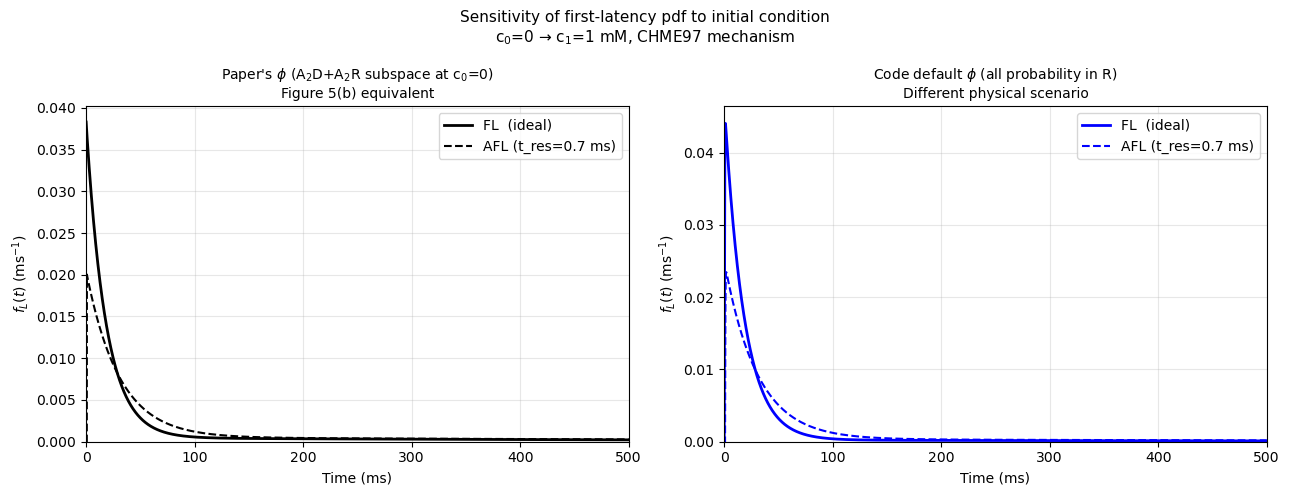

Mean first latency (paper phi):  219.94 ms
Mean first latency (code  phi):  122.20 ms


In [10]:
# Compare FL and AFL for both initial vectors
t_long  = np.linspace(0, 500, 5000) * 1e-3   # 0 to 500 ms in seconds
t_ms500 = t_long * 1000

fl_paper = fl.ideal_pdf(t_long, mec1.QFF, phi_paper) * 1e-3
fl_code  = fl.ideal_pdf(t_long, mec1.QFF, phi_code)  * 1e-3

roots_code  = fl.asymptotic_roots(tres, mec1)
areas_code  = fl.asymptotic_areas(tres, roots_code, phi_code, mec1)
tau_code    = -1.0 / roots_code
afl_paper   = fl.asymptotic_pdf(t_long, tres, tau_asym, areas_asym) * 1e-3
afl_code    = fl.asymptotic_pdf(t_long, tres, tau_code, areas_code)  * 1e-3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: paper's phi (Figure 5b equivalent)
ax = axes[0]
ax.plot(t_ms500, fl_paper,  'k-',  lw=2.0, label='FL  (ideal)')
ax.plot(t_ms500, afl_paper, 'k--', lw=1.5, label=f'AFL (t_res={tres*1000:.1f} ms)')
ax.set_title("Paper's $\phi$ (A$_2$D+A$_2$R subspace at c$_0$=0)\nFigure 5(b) equivalent",
             fontsize=10)
ax.set_xlabel('Time (ms)');  ax.set_ylabel('$f_L(t)$ (ms$^{-1}$)')
ax.set_xlim([0, 500]);  ax.set_ylim(bottom=0);  ax.legend();  ax.grid(alpha=0.3)

# Right: code default phi (all in R)
ax = axes[1]
ax.plot(t_ms500, fl_code,  'b-',  lw=2.0, label='FL  (ideal)')
ax.plot(t_ms500, afl_code, 'b--', lw=1.5, label=f'AFL (t_res={tres*1000:.1f} ms)')
ax.set_title("Code default $\phi$ (all probability in R)\nDifferent physical scenario",
             fontsize=10)
ax.set_xlabel('Time (ms)');  ax.set_ylabel('$f_L(t)$ (ms$^{-1}$)')
ax.set_xlim([0, 500]);  ax.set_ylim(bottom=0);  ax.legend();  ax.grid(alpha=0.3)

plt.suptitle(
    'Sensitivity of first-latency pdf to initial condition\n'
    'c$_0$=0 \u2192 c$_1$=1 mM, CHME97 mechanism', fontsize=11)
plt.tight_layout()
plt.show()

# Mean first latency
eigs_p, areas_p = fl.ideal_components(mec1.QFF, phi_paper)
eigs_c, areas_c = fl.ideal_components(mec1.QFF, phi_code)
mean_p = np.sum(areas_p / eigs_p) * 1000
mean_c = np.sum(areas_c / eigs_c) * 1000
print(f"Mean first latency (paper phi):  {mean_p:.2f} ms")
print(f"Mean first latency (code  phi):  {mean_c:.2f} ms")
